In [36]:
!pip install gymnax distrax
!git clone -b spring-2026 https://github.com/james116blue/game_theory_course.git

fatal: destination path 'game_theory_course' already exists and is not an empty directory.


In [37]:
import sys
sys.path.append('/content/game_theory_course')
sys.path.append('/content/game_theory_course/rl')

In [38]:
import jax
from jax import numpy as np
import gymnax
import warnings

warnings.filterwarnings('ignore')

Этот код демонстрирует взаимодействие со средой CartPole из библиотеки Gymnax (JAX-версия OpenAI Gym), запись последовательности состояний и наград, и создание анимированной визуализации.



Эпизод завершен


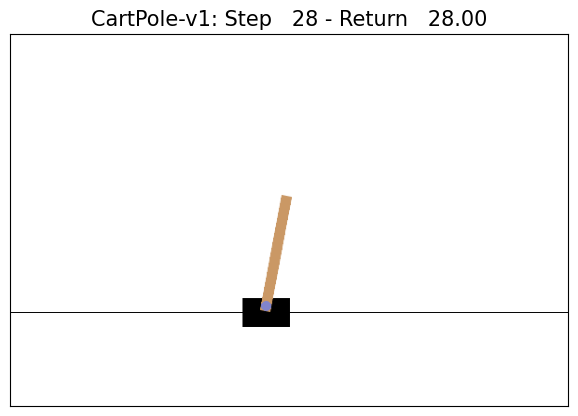

In [39]:
from visualize.visualizer import Visualizer

# 1. Инициализация структур данных для хранения состояний и наград
state_seq = []  # Будет хранить последовательность состояний среды
reward_seq = []  # Будет хранить последовательность полученных наград
# 2. Настройка генератора случайных чисел JAX
rng = jax.random.PRNGKey(0)  # Инициализация с seed=0 для воспроизводимости
rng, rng_reset = jax.random.split(rng)  # Разделение ключа для операции reset
# 3. Создание среды CartPole-v1 и получение её параметров
env, env_params = gymnax.make("CartPole-v1")  # env - объект среды, env_params - параметры
# 4. Сброс среды в начальное состояние
obs, env_state = env.reset(rng_reset, env_params)  # obs - наблюдение, env_state - состояние среды
# 5. Основной цикл взаимодействия со средой
while True:
    # 5.1 Сохраняем текущее состояние среды
    state_seq.append(env_state)
    # 5.2 Генерируем новые случайные ключи для различных операций
    rng, rng_act, rng_step = jax.random.split(rng, 3)
    # 5.3 Выбираем случайное действие из пространства действий
    action = env.action_space(env_params).sample(rng_act)
    # 5.4 Выполняем шаг в среде
    next_obs, next_env_state, reward, done, info = env.step(
        rng_step, env_state, action, env_params
    )
    # 5.5 Сохраняем полученную награду
    reward_seq.append(reward)
    # 5.6 Проверяем условие завершения эпизода
    if done:
        break  # Выход из цикла если эпизод завершен
    else:
        # 5.7 Обновляем текущие наблюдение и состояние среды
        obs = next_obs
        env_state = next_env_state
# 6. Вычисляем кумулятивные награды за эпизод
cum_rewards = np.cumsum(np.array(reward_seq))
# 7. Создаем объект для визуализации
vis = Visualizer(
    env,  # Объект среды
    env_params,  # Параметры среды
    state_seq,  # Последовательность состояний
    cum_rewards  # Кумулятивные награды
)
# 8. Генерируем и сохраняем анимацию
vis.animate("env.gif", view=False)  # Сохраняем в файл, не показывая сразу
# 9. Сообщение о завершении
print('Эпизод завершен')

![SegmentLocal](https://github.com/james116blue/game_theory_course/blob/spring-2026/rl/env.gif?raw=1 "случайный агент")

    Структура модели:

        Наследуется от nn.Module (базовый класс Flax для нейронных сетей)

        Имеет три полносвязных слоя (Dense):

            Два скрытых слоя по 64 нейрона каждый

            Один выходной слой с настраиваемым количеством нейронов (out_dims)

    Активации:

        После каждого скрытого слоя применяется функция активации ReLU

        На выходном слое активация не применяется (обычно это делается,  когда активация будет применяться отдельно)

    Особенности Flax:

        Параметры модели инициализируются в методе setup()

        Прямой проход (forward pass) определяется в методе __call__

        Модель является immutable (неизменяемой) и функциональной, что соответствует философии JAX

In [40]:
import flax.linen as nn

class Model(nn.Module):
    out_dims: int

    def setup(self):
        self.dense1 = nn.Dense(64)
        self.dense2 = nn.Dense(64)
        self.out = nn.Dense(self.out_dims)

    def __call__(self, x):
        x = self.dense1(x)
        x = nn.relu(x)

        x = self.dense2(x)
        x = nn.relu(x)

        x = self.out(x)

        return x

Тестируем модель

In [41]:
model = Model(out_dims=env.action_space(env_params).n)
obs, env_state = env.reset(rng_reset, env_params)
rng, model_rng = jax.random.split(rng)
model_params = model.init(model_rng, obs)
action_logits = model.apply(model_params, obs)
assert isinstance(action_logits, jax.numpy.ndarray), "вывод модели должен бьть jax numpy"
assert action_logits.shape == (env.action_space().n,), f"вывод модели должен иметь размерность, равную количеству действий среды {env.action_space(env_params).n}"

generate_session генерирует одну траекторию (сессию) взаимодействия агента со средой в рамках обучения с подкреплением.
Ключевые моменты:

    Входные параметры:

        env_params: Параметры среды.

        model_params: Параметры модели (например, нейронной сети), которая определяет политику агента.

        rng: Ключ случайности (JAX-style RNG) для воспроизводимости.

    Возвращаемые значения:

        states: Список наблюдений (состояний) среды.

        actions: Список действий, выбранных агентом.

        rewards: Список наград, полученных на каждом шаге.

        rng: Обновленный ключ случайности.

    Логика работы:

        Среда сбрасывается в начальное состояние (env.reset).

        В цикле агент выбирает действие на основе текущего наблюдения, используя модель (политику).

        Действие применяется к среде (env.step), получается новое состояние, награда и флаг завершения эпизода.

        Цикл продолжается, пока среда не вернет done=True.

In [42]:
import distrax

def generate_session(env_params, model_params, rng):
    states, actions, rewards = [], [], []

    rng, rng_reset = jax.random.split(rng)

    # СБРОС СРЕДЫ
    obs, env_state = env.reset(rng_reset, env_params)

    while True:
        states.append(obs)

        rng, rng_act, rng_step = jax.random.split(rng, 3)

        # ПОЛУЧАЕМ ЛОГИТЫ ОТ МОДЕЛИ
        action_logits = model.apply(model_params, obs)

        policy = distrax.Categorical(logits=action_logits)

        action = policy.sample(seed=rng_act)
        actions.append(action)

        # ШАГ СРЕДЫ
        next_obs, next_env_state, reward, done, info = env.step(
            rng_step, env_state, action, env_params
        )

        rewards.append(reward)

        if done:
            break
        else:
            obs = next_obs
            env_state = next_env_state

    return states, actions, rewards, rng

In [43]:
states, actions, rewards, rng = generate_session(env_params,  model_params, rng)
assert isinstance(states, list)
assert isinstance(actions, list)
assert isinstance(rewards, list)
assert len(states) == len(actions) == len(rewards) > 0
assert all(s.shape==env.observation_space(env_params).shape for s in states)

\begin{align*}
r_t &\to G_t = \sum_{k=t}^T r_i = r_t +  r_{t + 1} +  r_{t + 2} + \ldots + r_T&\\\\
r_0 &\to r_0 + r_{1} + r_{2} + \ldots + r_T&\\
r_1 &\to r_1 + r_{2} +  \ldots + r_T&\\
\end{align*}

In [44]:
def get_cumulative_rewards(rewards):
    return np.cumsum(np.array(rewards))[::-1] #Perform a reverse cumulative sum on a (jax) numpy array

### Задание функции потерь

Назначение: Функция вычисляет потери для обучения policy network, которая непосредственно предсказывает вероятности действий.

Работа с вероятностями:

    Сначала получает логиты (logits) из модели

    Преобразует их в логарифмированные вероятности через log_softmax

    Выбирает только вероятности для фактически выполненных действий

Взвешивание наградами:

    Логарифмы вероятностей взвешиваются кумулятивными наградами

    Это усиливает вероятности действий, которые привели к высоким наградам

    И ослабляет вероятности действий с низкими наградами

Оптимизация:

    Минимизация этой функции потерь эквивалентна максимизации ожидаемой награды

    Градиентный спуск будет увеличивать вероятность "хороших" действий

$$\nabla_\theta \hat J(\theta) \approx { 1 \over T } \sum_{t=1}^T  G_t \cdot \nabla_\theta \log \pi_\theta (a_t \mid s_t) $$
Когда вы вычисляете градиент следующей функции относительно весов сети, он станет в точности градиентом стратегии.
$$ \hat J(\theta) \approx { 1 \over T } \sum_{t=1}^T  G_t \cdot  \log \pi_\theta (a_t \mid s_t) $$

In [45]:
def loss_fn(model_params, states, actions, cumulative_rewards):
    # Вычисление логитов (сырых выходов модели) для каждого действия на основе текущих параметров модели и состояний
    logits = model.apply(model_params, states)
    # Преобразование логитов в логарифмы вероятностей действий с помощью log-softmax (для численной стабильности)
    log_probs = nn.log_softmax(logits)
    # Выбор логарифмов вероятностей только для тех действий, которые были фактически выбраны в опыте
    # Умножение на one-hot вектор действий и суммирование по оси действий (чтобы оставить только нужные log_probs)
    log_probs_for_actions = np.sum(log_probs * nn.one_hot(actions, env.action_space(env_params).n), axis=1)
    # Вычисление финального значения потерь как среднее по всем примерам из батча
    # Потери представляют собой взвешенную сумму логарифмов вероятностей, где веса - это кумулятивные награды
    loss = np.mean(cumulative_rewards * log_probs_for_actions)
    return loss

In [46]:
states = np.array(states)
actions = np.array(actions)
rewards = np.array(rewards)
cumulative_rewards = np.cumsum(np.array(rewards))[::-1]
loss_value = loss_fn(model_params,  states, actions, cumulative_rewards)
assert isinstance(loss_value, jax.numpy.ndarray)
assert loss_value.shape == ()

Функция выполняет один шаг обучения модели reinforcement learning на данных одного эпизода (сессии). Она:

    Обрабатывает сырые данные эпизода (состояния, действия, награды)

    Вычисляет кумулятивные награды

    Рассчитывает градиенты функции потерь

    Обновляет параметры модели градиентным спуском

Входные параметры:

    model_params - текущие параметры модели

    states - последовательность состояний в эпизоде

    actions - последовательность действий в эпизоде

    rewards - последовательность наград в эпизоде

    alpha - скорость обучения (learning rate)

Выходные значения:

    Обновлённые параметры модели

    Значение функции потерь

    Суммарная награда за эпизод

In [47]:
def train_on_session(model_params, states, actions, rewards, alpha=0.001):
    states = np.array(states)
    actions = np.array(actions)
    rewards = np.array(rewards)

    cumulative_rewards = np.cumsum(rewards[::-1])[::-1]

    loss_value, grads = jax.value_and_grad(loss_fn)(
        model_params, states, actions, cumulative_rewards
    )

    model_params = jax.tree.map(lambda x, y: x + alpha * y, model_params, grads)

    return model_params, loss_value, np.sum(rewards)

In [48]:
from jax.tree_util import tree_structure
states, actions, rewards, rng = generate_session(env_params,  model_params, rng)
new_model_params, loss_value, summary_reward = train_on_session( model_params, states, actions, rewards,)

assert tree_structure(model_params) == tree_structure(new_model_params)
assert isinstance(loss_value, jax.numpy.ndarray)
assert loss_value.shape == ()
assert isinstance(summary_reward, jax.numpy.ndarray)
assert summary_reward.shape == ()
assert summary_reward == sum(rewards)

общий алгоритм

In [ ]:
summary_reward_for_100_episodes = 0

for i in range(1, 1001):
    states, actions, rewards, rng = generate_session(env_params, model_params, rng)

    model_params, loss_value, summary_reward = train_on_session(
        model_params, states, actions, rewards
    )

    summary_reward_for_100_episodes += summary_reward

    if i % 100 == 0:
        print(f'average_summary_reward={summary_reward_for_100_episodes / 100}')
        summary_reward_for_100_episodes = 0

In [ ]:
# Instantiate the environment & its settings.
env, env_params = gymnax.make("CartPole-v1")
obs, env_state = env.reset(rng_reset, env_params)
state_seq, reward_seq = [], []
while True:
    state_seq.append(env_state)
    rng, rng_act, rng_step = jax.random.split(rng, 3)
    action_logits = model.apply(model_params, obs)
    action = np.argmax(action_logits) # NB
    next_obs, next_env_state, reward, done, info = env.step(
        rng_step, env_state, action, env_params
    )
    reward_seq.append(reward)
    if done:
        break
    else:
      obs = next_obs
      env_state = next_env_state

cum_rewards = np.cumsum(np.array(reward_seq))
vis = Visualizer(env, env_params, state_seq, cum_rewards)
vis.animate(f"trained_env.gif", view=False)

![SegmentLocal](https://github.com/james116blue/game_theory_course/blob/spring-2026/rl/anim.gif?raw=1 "обученная модель")